# Importing files from bucket

In [2]:
# Zip the folder (e.g., Dataset or outputs or a specific model file)
!zip -r dataset_archive.zip Dataset/

  adding: Dataset/ (stored 0%)
  adding: Dataset/Dataset/ (stored 0%)
  adding: Dataset/Dataset/train/ (stored 0%)
  adding: Dataset/Dataset/train/195.soda-can/ (stored 0%)
  adding: Dataset/Dataset/train/195.soda-can/195_0027.jpg (deflated 0%)
  adding: Dataset/Dataset/train/195.soda-can/195_0069.jpg (deflated 4%)
  adding: Dataset/Dataset/train/195.soda-can/195_0067.jpg (deflated 0%)
  adding: Dataset/Dataset/train/195.soda-can/195_0016.jpg (deflated 0%)
  adding: Dataset/Dataset/train/195.soda-can/195_0046.jpg (deflated 0%)
  adding: Dataset/Dataset/train/195.soda-can/195_0087.jpg (deflated 2%)
  adding: Dataset/Dataset/train/195.soda-can/195_0079.jpg (deflated 1%)
  adding: Dataset/Dataset/train/195.soda-can/195_0076.jpg (deflated 4%)
  adding: Dataset/Dataset/train/195.soda-can/195_0064.jpg (deflated 1%)
  adding: Dataset/Dataset/train/195.soda-can/195_0034.jpg (deflated 0%)
  adding: Dataset/Dataset/train/195.soda-can/195_0037.jpg (deflated 3%)
  adding: Dataset/Dataset/train/195

## Utility Function: Data Preprocessing

In [3]:
# Suppress TensorFlow logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Processing
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, activations, ops
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Visualising
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

E0000 00:00:1747837076.577367      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747837076.650304      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
def load_data(path_to_your_data_folder, h, w):
    dataset = tf.keras.utils.image_dataset_from_directory(
        path_to_your_data_folder,
        labels='inferred',
        color_mode="rgb",
        image_size=(h, w),
        batch_size=None,
        shuffle=True,
    )
    return dataset

def separate_dataset(dataset):
    X = []
    Y = []
    for image, label in dataset:
        X.append(image.numpy())
        Y.append(label.numpy())
    X = np.array(X)
    Y = np.array(Y).reshape(-1, 1)
    X = X / 255.0
    return X, Y

# Group images by category, where raw labels are encoded to their indexes for convenience
def group_images_by_category(dataset):
    images_by_category = defaultdict(list)
    for image, label in dataset:
        # This convert 001.ak47 -> 1, 002.america-flag -> 2, and so on
        label = int(label.numpy())
        images_by_category[label].append(image)
    return images_by_category

def plot_images_by_category_id(images_by_category, category_id): # Moidfied Kien's function to rgb
    images = images_by_category[category_id]
    fig = plt.figure(figsize=[10, 10])
    for i in range(min(25, len(images))):
        ax = fig.add_subplot(5, 5, i + 1)
        img = np.array(images[i])
        # Normalize if float image is in [0, 255]
        if img.dtype == np.float32 and img.max() > 1.0:
            img = img / 255.0
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def plot_images_by_dataset(dataset, X, Y, num): # Pass in the dataset (for names), the numpy X and numpy Y for visualisation
    fig = plt.figure(figsize=[10, 10])
    for i in range(min(num, len(X))):
        ax = fig.add_subplot(5, 5, i + 1)
        img = X[i]
        ax.imshow(img)
        label = Y[i][0] if isinstance(Y[i], (np.ndarray, list)) else Y[i]
        class_name = dataset.class_names[label]
        ax.set_title(f"Label {label}: {class_name}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## Sanity Checks: Files are working

In [5]:
# Loading all files into tensor dataset (Im spltting 70/15/15 for each class to make sure each dataset has all the classes)
train_dataset = load_data('Dataset/train', 64, 64)
val_dataset = load_data('Dataset/val', 64, 64)
test_dataset = load_data('Dataset/test', 64, 64)

Found 21307 files belonging to 257 classes.


I0000 00:00:1747837104.674173      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747837104.674988      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 4589 files belonging to 257 classes.
Found 4711 files belonging to 257 classes.


Category 2
Train Dataset


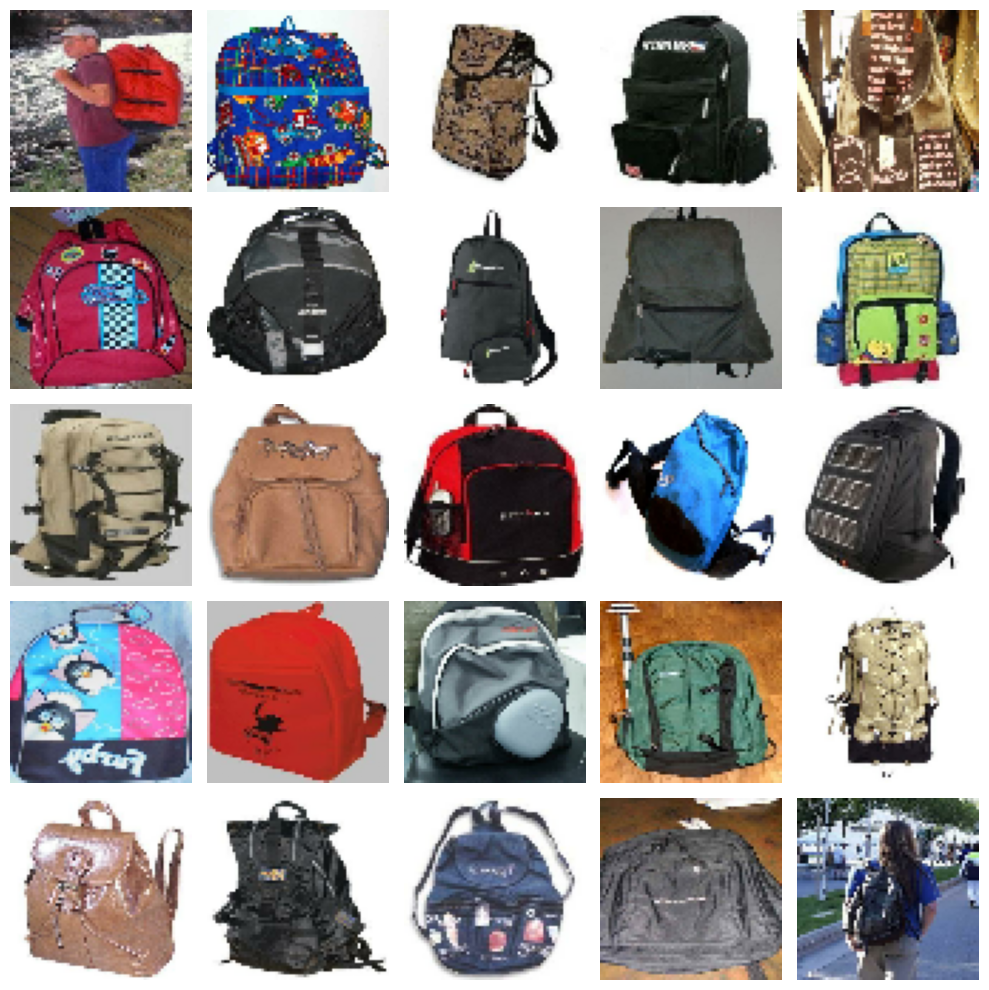

Validation Dataset


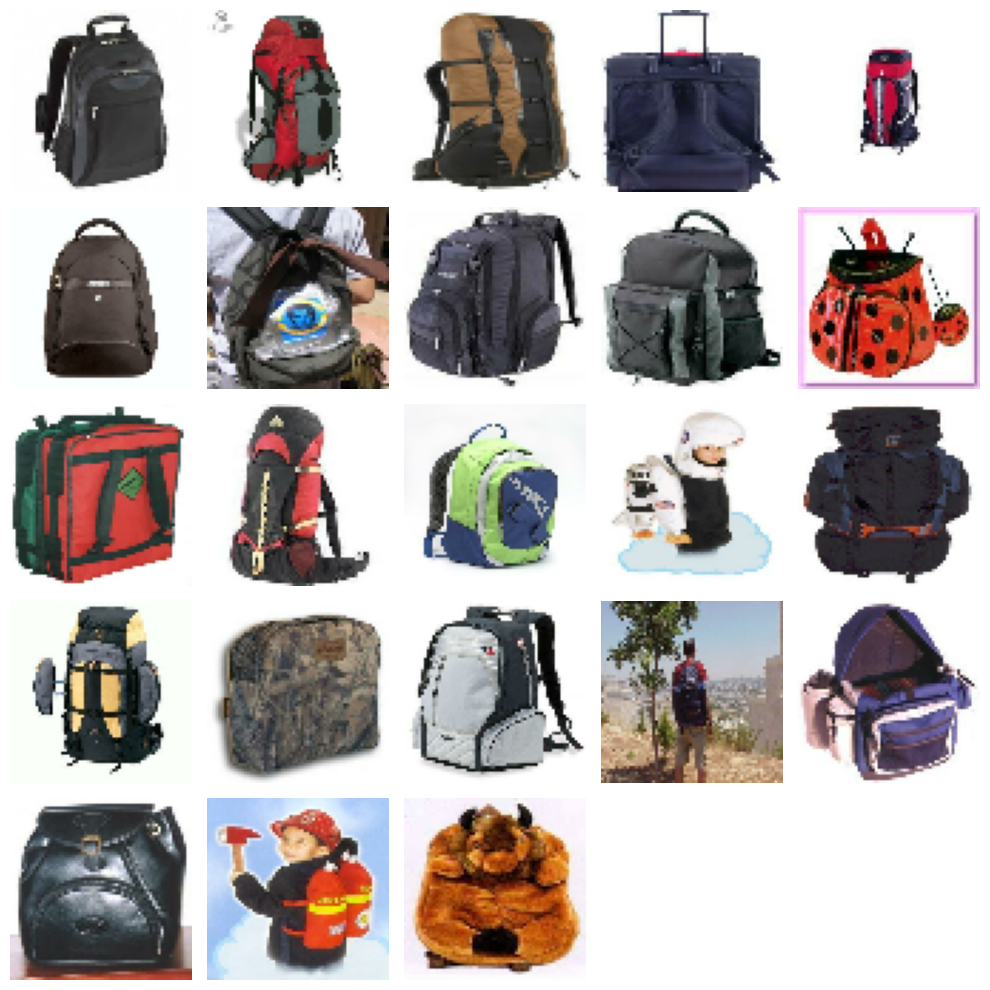

Test Dataset


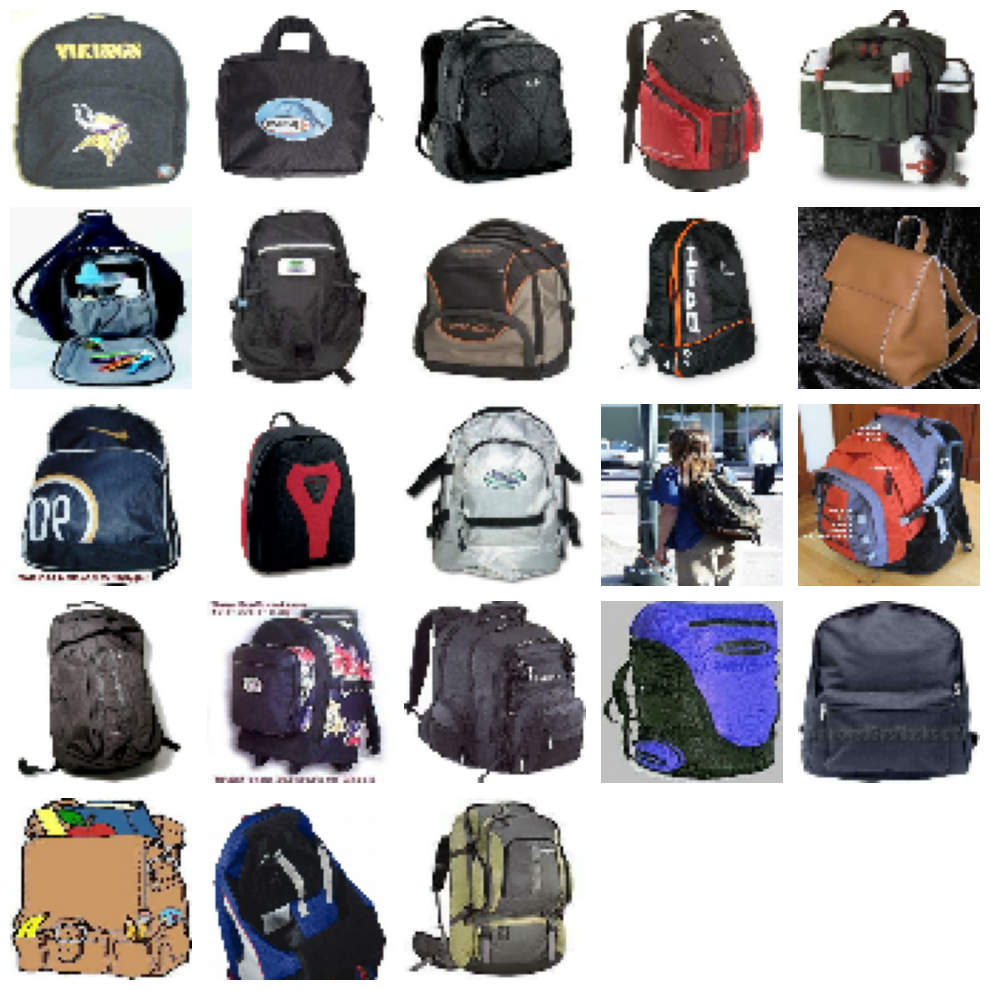

In [6]:
# Visualising for sanity check
train_category = group_images_by_category(train_dataset)
val_category = group_images_by_category(val_dataset)
test_category = group_images_by_category(test_dataset)

Category = 2
print(f"Category {Category}")
print("Train Dataset")
plot_images_by_category_id(train_category,Category)
print("Validation Dataset")
plot_images_by_category_id(val_category,Category)
print("Test Dataset")
plot_images_by_category_id(test_category,Category)

# Data Preparation

In [7]:
# Changing everything to numpy
train_X, train_Y = separate_dataset(train_dataset)
val_X, val_Y = separate_dataset(val_dataset)
test_X, test_Y = separate_dataset(test_dataset)

## Sanity Check

In [8]:
# Sanity Check whether shape is correct
print(train_X.shape)
print(train_Y.shape)
print(val_X.shape)
print(val_Y.shape)
print(test_X.shape)
print(test_Y.shape)

(21307, 64, 64, 3)
(21307, 1)
(4589, 64, 64, 3)
(4589, 1)
(4711, 64, 64, 3)
(4711, 1)


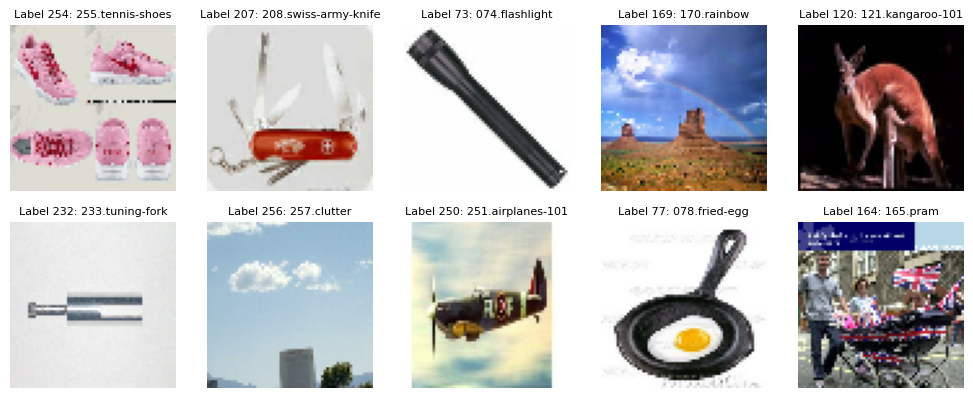

In [9]:
# Sanity Check to plot image
plot_images_by_dataset(val_dataset, val_X, val_Y, 10)

# Data Augmentation



In [10]:
# Data Augmentation layers
# Add more layers based on your preferences
# https://keras.io/api/layers/preprocessing_layers/image_augmentation/
def random_brightness_contrast_hue_saturation(image):
    image = tf.image.random_brightness(image, max_delta=0.1)  # ±10% brightness
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)  # ±10% contrast
    image = tf.image.random_hue(image, max_delta=0.05)  # ±5% hue
    image = tf.image.random_saturation(image, lower=0.9, upper=1.1)  # ±10% saturation
    return image

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.025),
    layers.RandomTranslation(height_factor=0.025, width_factor=0.025),
    layers.Lambda(lambda x: tf.map_fn(random_brightness_contrast_hue_saturation, x)),
])

# Model Building Components

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, BatchNormalization, concatenate
from tensorflow.keras import initializers
import tensorflow.keras.backend as K
from tensorflow.keras import regularizers


def _conv_layer(filters, kernel_size, strides=(1, 1), padding='same', name=None):
    return Conv2D(filters, kernel_size, strides=strides, padding=padding,
                  use_bias=True, kernel_initializer='he_normal',
                  kernel_regularizer=regularizers.l2(1e-4),  # Added L2 regularization
                  name=name)

def _normalize_depth_vars(depth_k, depth_v, filters):
    depth_k = int(filters * depth_k) if isinstance(depth_k, float) else int(depth_k)
    depth_v = int(filters * depth_v) if isinstance(depth_v, float) else int(depth_v)
    return depth_k, depth_v

class AttentionAugmentation2D(Layer):
    def __init__(self, depth_k, depth_v, num_heads, relative=True, **kwargs):
        super().__init__(**kwargs)
        if depth_k % num_heads != 0 or depth_v % num_heads != 0:
            raise ValueError("depth_k and depth_v must be divisible by num_heads")
        self.depth_k, self.depth_v, self.num_heads, self.relative = depth_k, depth_v, num_heads, relative
        self.axis = -1  # Assume channels_last

    def build(self, input_shape):
        _, height, width, _ = input_shape
        dk_per_head = self.depth_k // self.num_heads
        if self.relative:
            self.key_relative_w = self.add_weight(name='key_rel_w', shape=[2 * width - 1, dk_per_head],
                                                  initializer=initializers.RandomNormal(stddev=dk_per_head ** -0.5))
            self.key_relative_h = self.add_weight(name='key_rel_h', shape=[2 * height - 1, dk_per_head],
                                                  initializer=initializers.RandomNormal(stddev=dk_per_head ** -0.5))

    def call(self, inputs, **kwargs):
        q, k, v = tf.split(inputs, [self.depth_k, self.depth_k, self.depth_v], axis=-1)
        q, batch, height, width = self.split_heads_2d(q)
        k, _, _, _ = self.split_heads_2d(k)
        v, _, _, _ = self.split_heads_2d(v)

        q *= (self.depth_k / self.num_heads) ** -0.5

        qk_shape = tf.stack([batch, self.num_heads, height * width, self.depth_k // self.num_heads])
        v_shape = tf.stack([batch, self.num_heads, height * width, self.depth_v // self.num_heads])

        flat_q = tf.reshape(q, qk_shape)
        flat_k = tf.reshape(k, qk_shape)
        flat_v = tf.reshape(v, v_shape)

        logits = tf.matmul(flat_q, flat_k, transpose_b=True)

        if self.relative:
            h_rel_logits, w_rel_logits = self.relative_logits(q)
            logits += h_rel_logits + w_rel_logits

        weights = tf.nn.softmax(logits, axis=-1)
        attn_out = tf.matmul(weights, flat_v)

        attn_out_shape = tf.stack([batch, self.num_heads, height, width, self.depth_v // self.num_heads])
        attn_out = tf.reshape(attn_out, attn_out_shape)
        attn_out = self.combine_heads_2d(attn_out)

        return attn_out

    def split_heads_2d(self, ip):
        shape = tf.shape(ip)
        batch, height, width, channels = shape[0], shape[1], shape[2], shape[3]
        split_shape = tf.stack([batch, height, width, self.num_heads, channels // self.num_heads])
        split = tf.reshape(ip, split_shape)
        split = tf.transpose(split, perm=[0, 3, 1, 2, 4])
        return split, batch, height, width

    def relative_logits(self, q):
        shape = tf.shape(q)
        height, width = shape[2], shape[3]
        rel_logits_w = self.relative_logits_1d(q, self.key_relative_w, height, width, [0, 1, 2, 4, 3, 5])
        rel_logits_h = self.relative_logits_1d(tf.transpose(q, perm=[0, 1, 3, 2, 4]), self.key_relative_h, width, height, [0, 1, 4, 2, 5, 3])
        return rel_logits_h, rel_logits_w

    def relative_logits_1d(self, q, rel_k, H, W, transpose_mask):
        rel_logits = tf.einsum('bhxyd,md->bhxym', q, rel_k)
        rel_logits = tf.reshape(rel_logits, [-1, self.num_heads * H, W, 2 * W - 1])
        rel_logits = self.rel_to_abs(rel_logits)
        rel_logits = tf.reshape(rel_logits, [-1, self.num_heads, H, W, W])
        rel_logits = tf.expand_dims(rel_logits, axis=3)
        rel_logits = tf.tile(rel_logits, [1, 1, 1, H, 1, 1])
        rel_logits = tf.transpose(rel_logits, perm=transpose_mask)
        rel_logits = tf.reshape(rel_logits, [-1, self.num_heads, H * W, H * W])
        return rel_logits

    def rel_to_abs(self, x):
        shape = tf.shape(x)
        B, Nh, L = shape[0], shape[1], shape[2]
        col_pad = tf.zeros([B, Nh, L, 1], dtype=x.dtype)
        x = tf.concat([x, col_pad], axis=3)
        flat_x = tf.reshape(x, [B, Nh, L * 2 * L])
        flat_pad = tf.zeros([B, Nh, L - 1], dtype=x.dtype)
        flat_x_padded = tf.concat([flat_x, flat_pad], axis=2)
        final_x = tf.reshape(flat_x_padded, [B, Nh, L + 1, 2 * L - 1])
        return final_x[:, :, :L, L - 1:]

    def combine_heads_2d(self, inputs):
        inputs = tf.transpose(inputs, perm=[0, 2, 3, 1, 4])
        shape = tf.shape(inputs)
        batch, height, width, num_heads, depth_per_head = shape[0], shape[1], shape[2], shape[3], shape[4]
        new_shape = tf.stack([batch, height, width, num_heads * depth_per_head])
        return tf.reshape(inputs, new_shape)

    def get_config(self):
        config = {'depth_k': self.depth_k, 'depth_v': self.depth_v, 'num_heads': self.num_heads, 'relative': self.relative}
        base_config = super().get_config()
        return dict(list(base_config.items()) + list(config.items()))


def augmented_conv2d(ip, filters, kernel_size=(3, 3), strides=(1, 1), depth_k=0.2, depth_v=0.2, num_heads=8, relative_encodings=True):
    depth_k, depth_v = _normalize_depth_vars(depth_k, depth_v, filters)
    conv_out = _conv_layer(filters - depth_v, kernel_size, strides)(ip)
    qkv_conv = _conv_layer(2 * depth_k + depth_v, (1, 1), strides)(ip)
    attn_out = AttentionAugmentation2D(depth_k, depth_v, num_heads, relative_encodings)(qkv_conv)
    attn_out = _conv_layer(depth_v, kernel_size=(1, 1))(attn_out)
    output = concatenate([conv_out, attn_out], axis=-1)
    output = BatchNormalization()(output)
    return output

In [13]:
def basic_block(x, filters, strides=(1, 1), use_projection=False, apply_attention=True):
    shortcut = x
    if use_projection:
        shortcut = tf.keras.layers.Conv2D(filters, (1, 1), strides=strides, padding='same')(shortcut)
        shortcut = tf.keras.layers.BatchNormalization()(shortcut)

    if apply_attention:
        x = augmented_conv2d(x, filters, kernel_size=(3, 3), strides=strides,
                             depth_k=0.125, depth_v=0.125, num_heads=8)
    else:
        x = tf.keras.layers.Conv2D(filters, (3, 3), strides=strides, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([shortcut, x])
    x = tf.keras.layers.ReLU()(x)
    return x

In [14]:
def build_aa_resnet34(input_shape=(64, 64, 3), num_classes=257):
    inputs = tf.keras.Input(shape=input_shape)

    # Data Augmentation
    x = data_augmentation(inputs)

    # Initial Conv
    x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Stage 1 — NO attention (resolution is 64x64)
    x = basic_block(x, 64, use_projection=True, apply_attention=False)
    x = basic_block(x, 64, apply_attention=False)
    x = basic_block(x, 64, apply_attention=False)

    # Stage 2 — NO attention (resolution is 32x32)
    x = basic_block(x, 128, strides=(2, 2), use_projection=True, apply_attention=False)
    x = basic_block(x, 128, apply_attention=False)
    x = basic_block(x, 128, apply_attention=False)
    x = basic_block(x, 128, apply_attention=False)

    # Stage 3 — Optional attention (16x16)
    x = basic_block(x, 256, strides=(2, 2), use_projection=True, apply_attention=False)
    x = basic_block(x, 256, apply_attention=False)
    x = basic_block(x, 256, apply_attention=False)
    x = basic_block(x, 256, apply_attention=False)
    x = basic_block(x, 256, apply_attention=False)
    x = basic_block(x, 256, apply_attention=False)

    # Stage 4 — YES attention (8x8)
    x = basic_block(x, 512, strides=(2, 2), use_projection=True, apply_attention=True)
    x = basic_block(x, 512, apply_attention=True)
    x = basic_block(x, 512, apply_attention=True)

    # Classification
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.models.Model(inputs, outputs)

# Model Training

## Model Training

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import time

print("\nTraining Main Model (AA-ResNet)")
model = build_aa_resnet34(input_shape=(64, 64, 3), num_classes=257)

# Set custom learning rate
optimizer = Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
checkpoint_filepath = "aa_resnet_best2.weights.h5"
checkpoint_callback = ModelCheckpoint(
    checkpoint_filepath,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

# Measure training time
start_time = time.time()

history = model.fit(
    train_X, train_Y,
    validation_data=(val_X, val_Y),
    batch_size=16,
    epochs=50,
    callbacks=[early_stopping, checkpoint_callback, reduce_lr],
    verbose=1
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal training time: {elapsed_time:.2f} seconds ({elapsed_time / 60:.2f} minutes)")



Training Main Model (AA-ResNet)
Epoch 1/50


I0000 00:00:1747837251.654596     463 cuda_dnn.cc:529] Loaded cuDNN version 90300


1332/1332 ━━━━━━━━━━━━━━━━━━━━ 308s 197ms/step - accuracy: 0.0622 - loss: 5.8226 - val_accuracy: 0.1118 - val_loss: 5.1882 - learning_rate: 1.0000e-04
Epoch 2/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 259s 195ms/step - accuracy: 0.1121 - loss: 5.0583 - val_accuracy: 0.1440 - val_loss: 4.9094 - learning_rate: 1.0000e-04
Epoch 3/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 259s 194ms/step - accuracy: 0.1623 - loss: 4.5695 - val_accuracy: 0.1582 - val_loss: 4.6724 - learning_rate: 1.0000e-04
Epoch 4/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 259s 195ms/step - accuracy: 0.2203 - loss: 4.1263 - val_accuracy: 0.2057 - val_loss: 4.2848 - learning_rate: 1.0000e-04
Epoch 5/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 259s 195ms/step - accuracy: 0.2674 - loss: 3.7651 - val_accuracy: 0.2486 - val_loss: 3.9253 - learning_rate: 1.0000e-04
Epoch 6/50
1332/1332 ━━━━━━━━━━━━━━━━━━━━ 259s 195ms/step - accuracy: 0.3131 - loss: 3.4854 - val_accuracy: 0.2728 - val_loss: 3.9365 - learning_rate: 1.0000e-04
Epoch 7/50
1332/1332 ━━━━━━━━━━━━━━━━━━

In [16]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ sequential (Sequential)   │ (None, 64, 64, 3)      │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 32)     │            896 │ sequential[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 64, 64, 32)     │            128 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu (ReLU)              │ (None, 64, 64, 32)     │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 64)     │         18,496 │ re_lu[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 64)     │            256 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_1 (ReLU)            │ (None, 64, 64, 64)     │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 64)     │          2,112 │ re_lu[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ re_lu_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 64, 64, 64)     │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 64)     │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 64, 64, 64)     │              0 │ batch_normalization_1… │
│                           │                        │                │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_2 (ReLU)            │ (None, 64, 64, 64)     │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ re_lu_2[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 64, 64, 64)     │            256 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_3 (ReLU)       

 Total params: 62,783,861 (239.50 MB)

 Trainable params: 20,922,257 (79.81 MB)

 Non-trainable params: 17,088 (66.75 KB)

 Optimizer params: 41,844,516 (159.62 MB)

In [17]:
test_loss, test_acc = model.evaluate(test_X, test_Y)
print(f"Test Accuracy: {test_acc:.4f}")

148/148 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.4960 - loss: 2.6225
Test Accuracy: 0.4886


In [20]:
from sklearn.metrics import classification_report
import pandas as pd

def evaluate_model_numpy(model, history, test_X, test_Y, class_names):
    print("Measuring inference time...")
    start_time = time.time()
    preds = model.predict(test_X, verbose=1)
    y_pred = np.argmax(preds, axis=1)
    y_true = test_Y
    inference_time = time.time() - start_time
    print(f"Inference time: {inference_time:.2f} seconds")

    # Accuracy
    test_loss, test_accuracy = model.evaluate(test_X, test_Y, verbose=1)
    print('Test loss:', test_loss)
    print('Test accuracy:', test_accuracy)

    # === CLASSIFICATION REPORT ===
    report = classification_report(y_true, y_pred, output_dict=True)
    df = pd.DataFrame(report).T
    df = df[df.index.str.isdigit()]
    df.index = df.index.astype(int).map(lambda i: class_names[i])
    df["accuracy"] = df.apply(lambda row: row["recall"], axis=1)  # recall == TP / (TP + FN), so same as class-level accuracy

    top10_accuracy = df.sort_values(by="accuracy", ascending=False).head(10)
    bottom10_accuracy = df.sort_values(by="accuracy", ascending=True).head(10)
    top10_precision = df.sort_values(by="precision", ascending=False).head(10)
    bottom10_precision = df.sort_values(by="precision", ascending=True).head(10)
    top10_recall = df.sort_values(by="recall", ascending=False).head(10)
    bottom10_recall = df.sort_values(by="recall", ascending=True).head(10)

    print("🔼 Top 10 Classes by Precision:\n", top10_precision[["precision", "recall", "f1-score"]])
    print("\n🔽 Bottom 10 Classes by Precision:\n", bottom10_precision[["precision", "recall", "f1-score"]])
    print("\n🔼 Top 10 Classes by Recall:\n", top10_recall[["precision", "recall", "f1-score"]])
    print("\n🔽 Bottom 10 Classes by Recall:\n", bottom10_recall[["precision", "recall", "f1-score"]])
    print("🔼 Top 10 Classes by Accuracy:\n", top10_accuracy[["precision", "recall", "f1-score", "accuracy"]])
    print("\n🔽 Bottom 10 Classes by Accuracy:\n", bottom10_accuracy[["precision", "recall", "f1-score", "accuracy"]])

    # Plot loss/accuracy
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.plot(history.history['accuracy'], label='Training Accuracy')
    ax.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Value')
    ax.legend()
    plt.show()

In [19]:
class_names = test_dataset.class_names


=== Evaluation: AA-ResNet (Attention) ===
Measuring inference time...
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step
Inference time: 18.60 seconds
148/148 ━━━━━━━━━━━━━━━━━━━━ 13s 87ms/step - accuracy: 0.4884 - loss: 2.6303
Test loss: 2.6507201194763184
Test accuracy: 0.48376139998435974
🔼 Top 10 Classes by Precision:
                     precision    recall  f1-score
204.sunflower-101    1.000000  0.833333  0.909091
241.waterfall        1.000000  0.200000  0.333333
243.welding-mask     1.000000  0.285714  0.444444
252.car-side-101     1.000000  0.888889  0.941176
251.airplanes-101    0.982759  0.950000  0.966102
253.faces-easy-101   0.970588  1.000000  0.985075
137.mars             0.952381  0.833333  0.888889
021.breadmaker       0.937500  0.681818  0.789474
145.motorbikes-101   0.937008  0.991667  0.963563
177.saturn           0.928571  0.866667  0.896552

🔽 Bottom 10 Classes by Precision:
                 precision    recall  f1-score
056.dog          0.000000  0.000000  0.000000
108

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


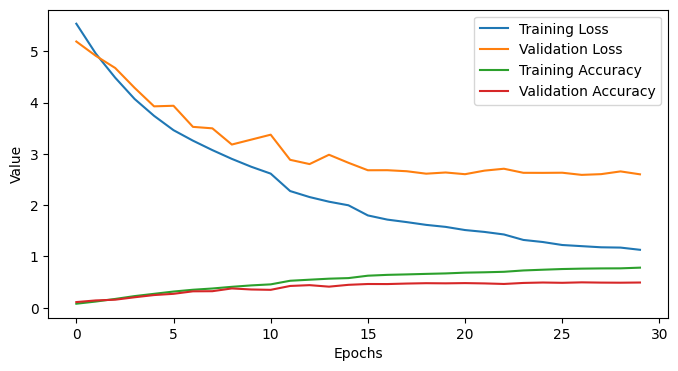

In [21]:
# Evaluate
print("\n=== Evaluation: AA-ResNet (Attention) ===")
evaluate_model_numpy(model, history, test_X, test_Y, class_names)

In [26]:
import matplotlib.pyplot as plt

def plot_training_history(history, title='Training History'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.suptitle(f'{title}', fontsize=16)

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train Acc')
    plt.plot(epochs, val_acc, label='Val Acc')
    plt.title('Train & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Val Loss')
    plt.title('Train & Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

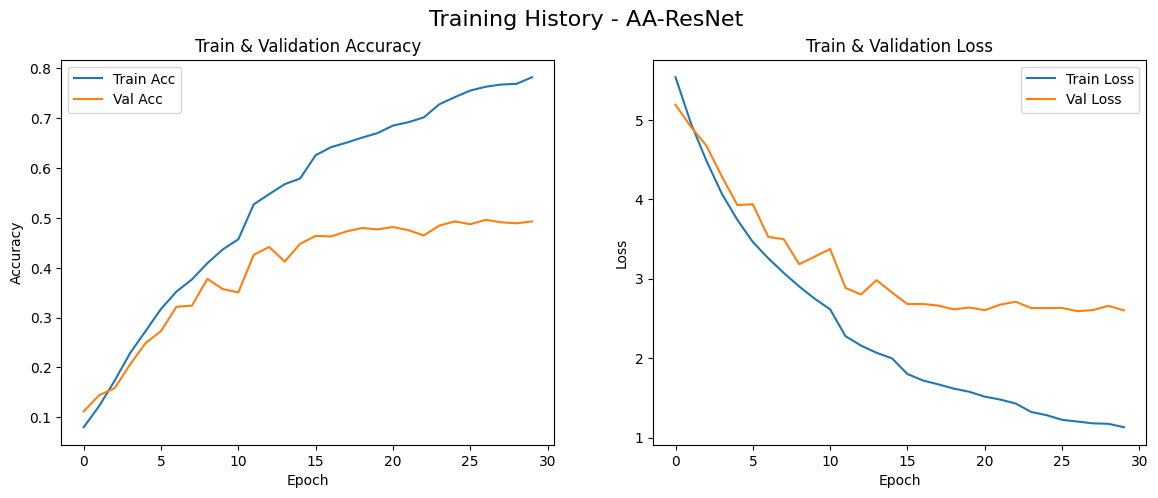

In [27]:
plot_training_history(history, title='Training History - AA-ResNet')

In [32]:
def collect_predictions(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

In [29]:
testds = tf.keras.utils.image_dataset_from_directory(
    "Dataset/test",
    image_size=(64, 64),
    label_mode="int",
    batch_size=32
)

# Normalize
testds = testds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

Found 4711 files belonging to 257 classes.


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Collect predictions from dataset
y_true, y_pred = collect_predictions(model, testds)

# Compute metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Print results
print("\n=== Evaluation Summary ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall    (Macro): {recall:.4f}")
print(f"F1-score  (Macro): {f1:.4f}")


=== Evaluation Summary ===
Accuracy : 0.4865
Precision (Macro): 0.4711
Recall    (Macro): 0.4427
F1-score  (Macro): 0.4384


In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
def plot_most_confused_pairs(dataset, confusion_pairs, class_names, n_samples=5):
    for _, row in confusion_pairs.iterrows():
        actual_class = row["Actual"]
        predicted_class = row["Predicted"]
        actual_class_id = class_names.index(actual_class)

        print(f"\nExamples of Actual '{actual_class}' Mistaken as '{predicted_class}':")

        imgs = []
        for batch in dataset:
            images, labels = batch  # each is a batch tensor
            for img, lbl in zip(images, labels):
                if tf.squeeze(lbl).numpy() == actual_class_id:
                    imgs.append(img.numpy())
                    if len(imgs) >= n_samples:
                        break
            if len(imgs) >= n_samples:
                break

        if not imgs:
            print(f"No images found for class {actual_class}")
            continue

        fig, axes = plt.subplots(1, len(imgs), figsize=(15, 3))
        for ax, img in zip(axes, imgs):
            img = np.array(img)
            if img.max() > 1.0:
                img = img / 255.0  # Normalize float image
            ax.imshow(img)
            ax.axis('off')
        fig.suptitle(f"Actual: {actual_class} mistaken as {predicted_class}", fontsize=14)
        plt.tight_layout()
        plt.show()


def find_top_confusion_pairs(y_true, y_pred, class_names, top_n=5):
    cm = confusion_matrix(y_true, y_pred)
    np.fill_diagonal(cm, 0)
    flat = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j:
                flat.append((class_names[i], class_names[j], cm[i, j]))
    df = pd.DataFrame(flat, columns=["Actual", "Predicted", "Count"]).sort_values("Count", ascending=False)
    return df.head(top_n)

In [36]:
top_confusion_pairs = find_top_confusion_pairs(y_true, y_pred, class_names, top_n=10)
print(top_confusion_pairs)

                 Actual       Predicted  Count
65214  255.tennis-shoes     191.sneaker      7
8636      034.centipede       190.snake      6
1886        008.bathtub     096.hammock      5
49698      195.soda-can  035.cereal-box      5
20779        082.galaxy       044.comet      5
35327      138.mattress     257.clutter      5
31071         122.kayak     096.hammock      5
1928        008.bathtub    138.mattress      4
9560          038.chimp     090.gorilla      4
48014    188.smokestack     143.minaret      4



Examples of Actual '255.tennis-shoes' Mistaken as '191.sneaker':


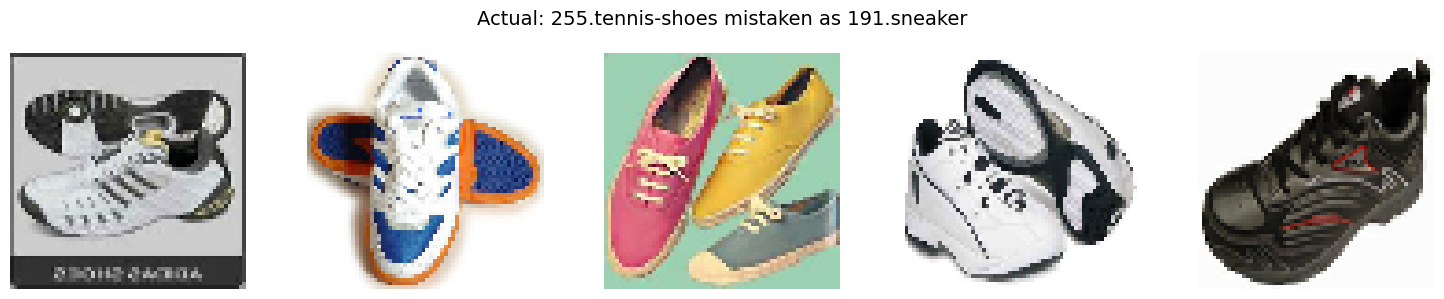


Examples of Actual '034.centipede' Mistaken as '190.snake':


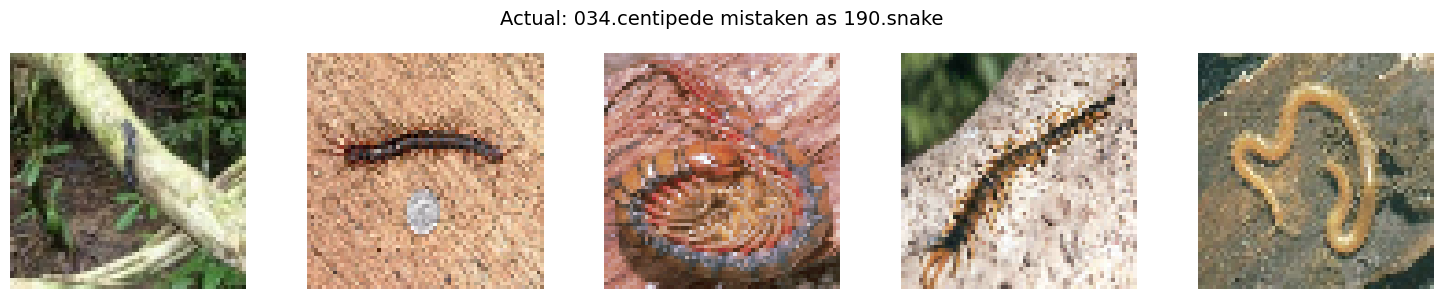


Examples of Actual '008.bathtub' Mistaken as '096.hammock':


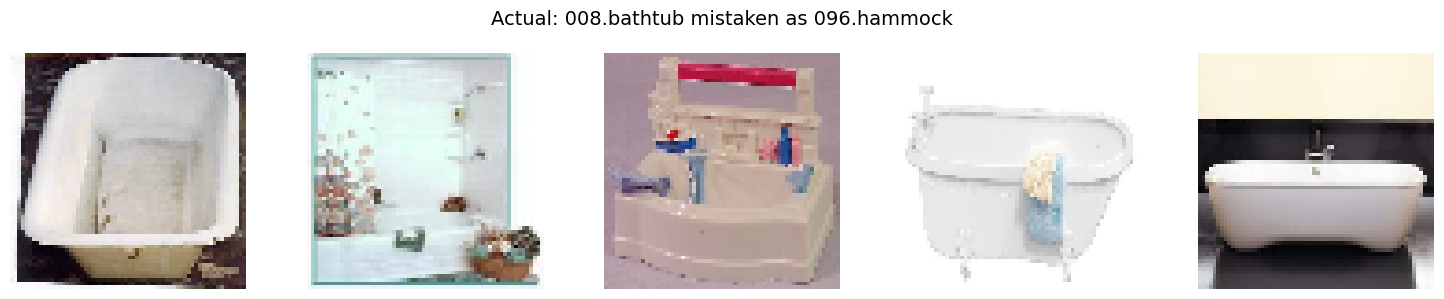


Examples of Actual '195.soda-can' Mistaken as '035.cereal-box':


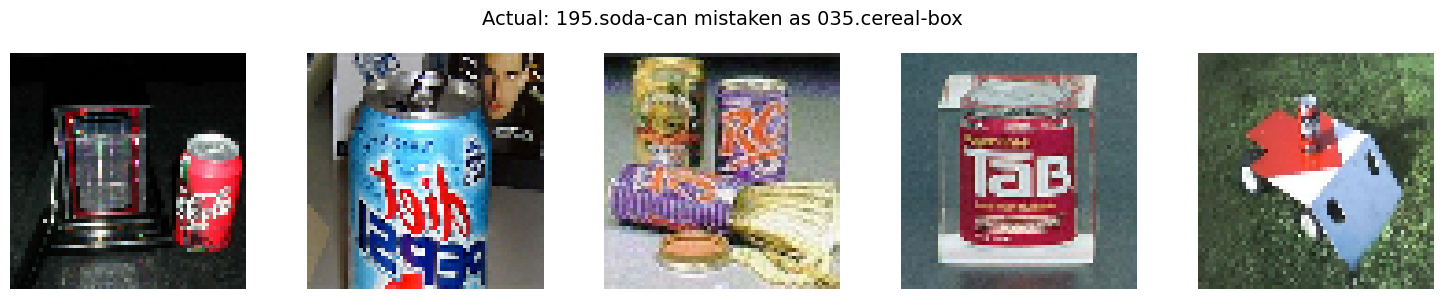


Examples of Actual '082.galaxy' Mistaken as '044.comet':


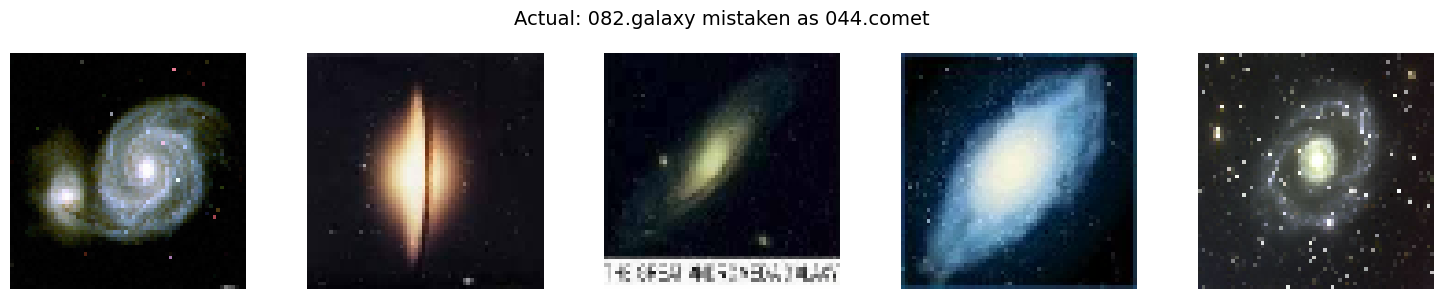


Examples of Actual '138.mattress' Mistaken as '257.clutter':


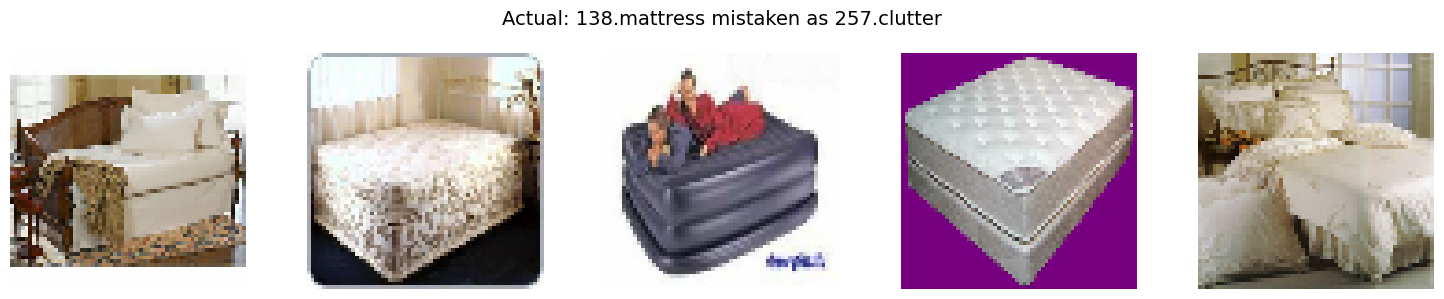


Examples of Actual '122.kayak' Mistaken as '096.hammock':


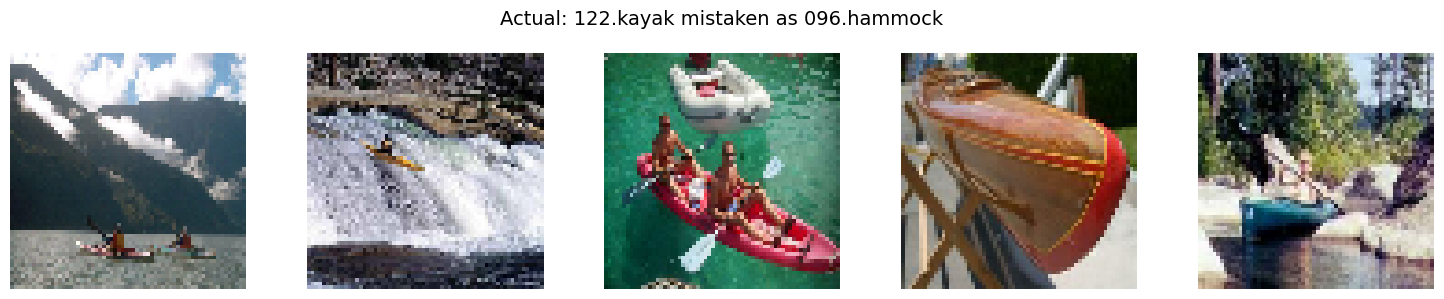


Examples of Actual '008.bathtub' Mistaken as '138.mattress':


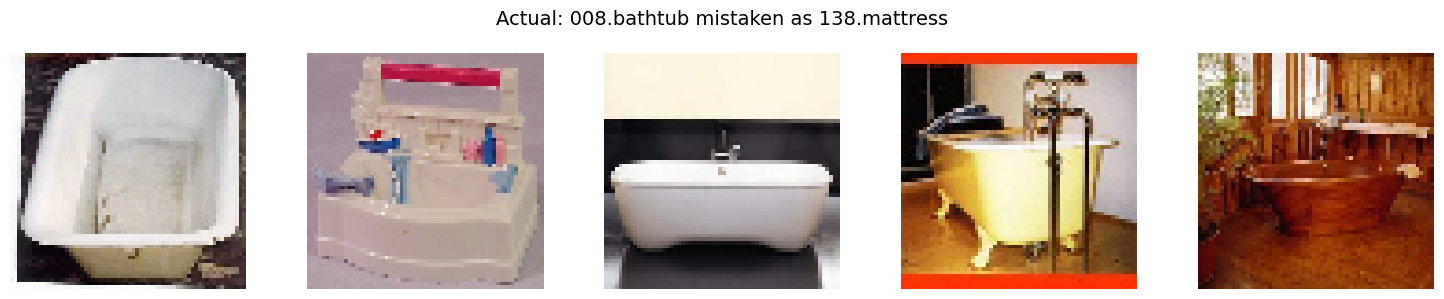


Examples of Actual '038.chimp' Mistaken as '090.gorilla':


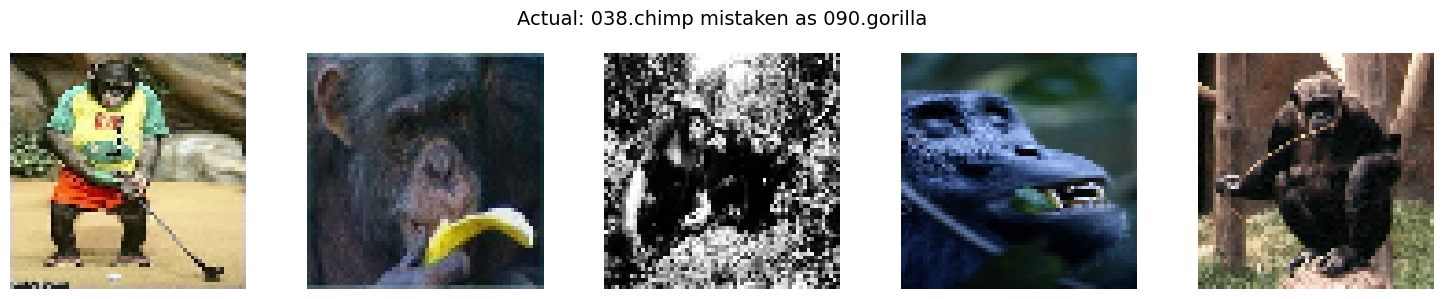


Examples of Actual '188.smokestack' Mistaken as '143.minaret':


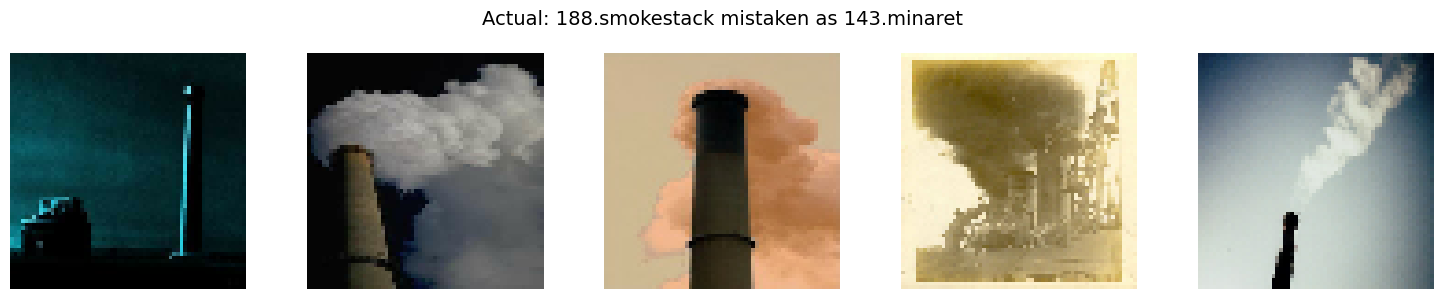

In [37]:
plot_most_confused_pairs(testds, top_confusion_pairs, class_names, n_samples=5)

In [45]:
model.save_weights("aa_resnet_best2.weights.h5")

In [46]:
import os
print(os.listdir('/kaggle/working'))

['dataset_archive.zip', 'Dataset', 'aa_resnet_best.weights.h5', 'aa_resnet_best2.weights.h5', '.virtual_documents']


In [39]:
!gsutil cp aa_resnet_best2.weights.h5 gs://chonlita_bucket/

CommandException: No URLs matched: aa_resnet_best2.weights.h5
